# Text Analytics Coursework (Group 37 - Task 2)



In [1]:
# !pip install datasets
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd


# Task 2 - EBM-NLP

This dataset is provided at https://github.com/bepnye/EBM-NLP and a copy has been made available in this repository for convenience. The data will need to be unzipped:

# 1) Data Preparation

In [2]:
import tarfile
import os

path_tofile = "../EBM-NLP-master/ebm_nlp_2_00.tar.gz"
extract_directory = os.path.dirname(path_tofile)

if tarfile.is_tarfile(path_tofile):
    with tarfile.open(path_tofile) as f:
        f.extractall(path=extract_directory)  # Extract all members from the archive to the current working directory


The data contains text documents that are annotated for mentions of participants, interventions and outcomes (PIO) in medical research. For each entity type, P, I, or O, there is a slightly different set of documents in the training and test set. Most of the documents are identical, but each type has a few extra documents. So, let's deal with each type separately for now.

To load the text documents, we first make a list of the document IDs for one entity type (P, I or O):

In [3]:
from pathlib import Path

DATA_DIR = Path("../EBM-NLP-master/ebm_nlp_2_00")

docs_dir = DATA_DIR / "documents"

def get_doc_ids(split="train", label_type="participants"):
    """ 
    split: 'train' or 'test' 
    label_type: 'participants', 'interventions', or 'outcomes'

    """
    if split == "test":
        split = "test/gold"

    split_dir = (
        DATA_DIR
        / "annotations"
        / "aggregated"
        / "hierarchical_labels"
        / label_type  # assuming that the split is the same for all entity types, we can just look at one of them
        / split
    )
    
    doc_ids = [p.name.replace(".AGGREGATED.ann", "") for p in split_dir.glob("*.AGGREGATED.ann")]
    # doc_ids = [p.name.replace("_AGGREGATED.ann", "") for p in split_dir.glob("*_AGGREGATED.ann")] for ebm_nlp_1_00.tar.gz files
    print(doc_ids)
    return sorted(doc_ids)

doc_ids_p = get_doc_ids("train", "participants")
test_doc_ids_p = get_doc_ids("test", "participants")

print(f"Number of documents in train split for participants: {len(doc_ids_p)}")
print(f"Number of documents in test split for participants: {len(test_doc_ids_p)}")


['16730541', '23766737', '17715164', '1578953', '11547366', '125133', '25022248', '21978765', '4818631', '7814161', '11034934', '9587285', '6307704', '9761783', '23760519', '10197379', '22007005', '22638779', '15738536', '8499152', '11700823', '12123333', '11362629', '26317618', '11315533', '16089221', '23052635', '16864886', '6261782', '23874533', '11378833', '1990041', '8245359', '25225951', '20854436', '22917554', '8644646', '19232615', '7564450', '17868242', '25555877', '9394942', '1530836', '18512510', '16904970', '24281134', '352099', '9607867', '3859359', '18855271', '18635304', '7593098', '25629971', '22588803', '22485232', '17482439', '23361105', '3075724', '25040756', '11476129', '12546485', '8123947', '21574725', '14519754', '19931151', '3818024', '20598044', '1408861', '24061784', '22808053', '15889546', '8561059', '25807670', '23619951', '9751681', '25907208', '21097567', '21424566', '2968595', '18166533', '19897177', '21432860', '25733274', '24035299', '9088586', '1912717

Now, we can get the annotations for the first entity type:

In [4]:
def load_labels_for_doc(doc_id, label_type="participants", split="train"):
    """
    split: 'train' or 'test' 
    label_type: 'participants', 'interventions', or 'outcomes'

    """
    if split == "test":
        split = "test/gold"

    ann_path = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels" / label_type / split/ f"{doc_id}.AGGREGATED.ann"
    
    if not ann_path.exists():
        print(ann_path, "does not exist!")
        return None
    
    with open(ann_path, "r", encoding="utf-8") as f:
        labels = [line.strip() for line in f]
    
    return labels

def load_labels(doc_ids, label_type="participants", split="train"):
    labels = []
    for doc_id in doc_ids:
        doc_labels = load_labels_for_doc(doc_id, label_type, split)
        if doc_labels is not None:
            labels.append(doc_labels)
    return labels

participants_labels = load_labels(doc_ids_p, "participants", split="train")

print(f"Length of participants_labels: {len(participants_labels)}")

test_participants_labels = load_labels(test_doc_ids_p, "participants", split="test")
print(f"Length of test_participants_labels: {len(test_participants_labels)}")

sample = 123
print("Document ID:", doc_ids_p[sample])
print(f"Participants label example for doc {doc_ids_p[sample]}:")
print(participants_labels[sample])

Length of participants_labels: 4609
Length of test_participants_labels: 189
Document ID: 10674680
Participants label example for doc 10674680:
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '4', '4', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '1', '1', '1', '1', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '3', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '

In [5]:
from itertools import chain
import numpy as np

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset
print(np.unique(list(all_labels)))

['0' '1' '2' '3' '4']


Let's look at what labels there are for Participants. The code above shows there are four values: 0 corresponds to 'outside' but 1-4 all indicate tokens that form an entity span. Each number is a level in a hierarchy of specificity. To start with let's not worry about this 'hierarchy'. We can instead just turn the labels into simple BIO (Beginning of a span, Inside a span, and Outside a span) tags.

In [6]:
def hierarchical_to_bio(tags):
    """
    Convert EBM-NLP hierarchical labels (0–4) to flat BIO tags.

    Parameters
    ----------
    tags : list[int]
        A list of hierarchical labels for a single document.

    Returns
    -------
    list[str]
        BIO tags ("O", "B", "I").
    """

    bio = []
    prev = 0

    for t in tags:
        t = int(t)  # ensure it's an integer
        if t == 0:
            bio.append("O")
        else:
            if prev == 0:
                bio.append("B")
            else:
                bio.append("I") 
                # The key point here is that we ignore changes in hierarchy, such as 1→2 or 2→3, 
                # and simply treat any sequence of non-zero values as falling within the same span.

        prev = t
        
    return bio


def convert_all_labels_to_bio(labels):
    for i, doc_labels in enumerate(labels):
        labels[i] = hierarchical_to_bio(doc_labels)
    return labels

participants_labels = convert_all_labels_to_bio(participants_labels)
test_participants_labels = convert_all_labels_to_bio(test_participants_labels)

all_labels = chain(*participants_labels)

# show how many unique labels there are across the dataset
print(np.unique(list(all_labels)))

['B' 'I' 'O']


So far, we've loaded the document IDs for participants and the corresponding labels. Now, let's load the documents themselves. They are already tokenised so that the labels match up with the tokens:

In [7]:
def load_document(doc_id):
    doc_path = DATA_DIR / "documents" / f"{doc_id}.tokens"
    with open(doc_path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]

def load_documents(doc_ids):
    documents = []
    for doc_id in doc_ids:
        doc = load_document(doc_id)
        documents.append(doc)
    return documents

participants_tokens = load_documents(doc_ids_p)
test_participants_tokens = load_documents(test_doc_ids_p)

# inspect a random element
print("Document ID:", doc_ids_p[sample])
print(f"Tokenised document example for doc {doc_ids_p[sample]}:")
print(participants_tokens[sample])


Document ID: 10674680
Tokenised document example for doc 10674680:
['Assessment', 'of', 'therapeutic', 'response', 'of', 'Plasmodium', 'falciparum', 'to', 'chloroquine', 'and', 'sulfadoxine-pyrimethamine', 'in', 'an', 'area', 'of', 'low', 'malaria', 'transmission', 'in', 'Colombia', '.', 'Although', 'chloroquine', '(', 'CQ', ')', 'resistance', 'was', 'first', 'reported', 'in', 'Colombia', 'in', '1961', 'and', 'sulfadoxine-pyrimethamine', '(', 'SP', ')', 'resistance', 'in', '1981', ',', 'the', 'frequency', 'of', 'treatment', 'failures', 'to', 'these', 'drugs', 'in', 'Colombia', 'is', 'unclear', '.', 'A', 'modified', 'World', 'Health', 'Organization', '14-day', 'in', 'vivo', 'drug', 'efficacy', 'test', 'for', 'uncomplicated', 'Plasmodium', 'falciparum', 'malaria', 'in', 'areas', 'with', 'intense', 'malaria', 'transmission', 'was', 'adapted', 'to', 'reflect', 'the', 'clinical', 'and', 'epidemiologic', 'features', 'of', 'a', 'low-intensity', 'malaria', 'transmission', 'area', 'in', 'the', 

### Interventions

In [8]:
doc_ids_i = get_doc_ids("train", "interventions")
test_doc_ids_i = get_doc_ids("test", "interventions")

print(f"Number of documents in train split for interventions: {len(doc_ids_i)}")
print(f"Number of documents in test split for interventions: {len(test_doc_ids_i)}")

interventions_tokens = load_documents(doc_ids_i)
test_interventions_tokens = load_documents(test_doc_ids_i)

['16730541', '23766737', '1578953', '11547366', '125133', '25022248', '21978765', '4818631', '7814161', '11034934', '9587285', '6307704', '9761783', '23760519', '10197379', '22007005', '22638779', '15738536', '8499152', '11700823', '12123333', '11362629', '26317618', '11315533', '16089221', '23052635', '25795561', '24274627', '16864886', '19638081', '6261782', '23874533', '11378833', '26035186', '1990041', '8245359', '25225951', '20854436', '22917554', '8644646', '19232615', '7564450', '17868242', '25555877', '16006861', '9394942', '1530836', '18512510', '16904970', '24281134', '352099', '9607867', '3859359', '18855271', '18635304', '7593098', '25629971', '22588803', '22485232', '17482439', '23361105', '3075724', '25040756', '11476129', '12546485', '8123947', '21574725', '14519754', '19931151', '3818024', '20598044', '1408861', '24061784', '22808053', '15889546', '8561059', '25807670', '23619951', '9751681', '25907208', '21097567', '21424566', '2968595', '18166533', '19897177', '214328

In [9]:
interventions_labels = load_labels(doc_ids_i, "interventions", split="train")
print(f"Length of interventions_labels: {len(interventions_labels)}")

test_interventions_labels = load_labels(test_doc_ids_i, "interventions", split="test")
print(f"Length of test_interventions_labels: {len(test_interventions_labels)}")

interventions_labels = convert_all_labels_to_bio(interventions_labels)
test_interventions_labels = convert_all_labels_to_bio(test_interventions_labels)

Length of interventions_labels: 4746
Length of test_interventions_labels: 187


### Outcomes

In [10]:
doc_ids_o = get_doc_ids("train", "outcomes")
test_doc_ids_o = get_doc_ids("test", "outcomes")

print(f"Number of documents in train split for outcomes: {len(doc_ids_o)}")
print(f"Number of documents in test split for outcomes: {len(test_doc_ids_o)}")

outcomes_tokens = load_documents(doc_ids_o)
test_outcomes_tokens = load_documents(test_doc_ids_o)

['16730541', '23766737', '17715164', '1578953', '11547366', '125133', '25022248', '21978765', '4818631', '7814161', '11034934', '9587285', '6307704', '9761783', '10197379', '22007005', '22638779', '15738536', '8499152', '11700823', '12123333', '11362629', '11315533', '16089221', '23052635', '25795561', '24274627', '16864886', '19638081', '6261782', '23874533', '11378833', '26035186', '1990041', '8245359', '25225951', '20854436', '22917554', '8644646', '19232615', '7564450', '17868242', '25555877', '16006861', '9394942', '1530836', '18512510', '16904970', '24281134', '352099', '9607867', '3859359', '18855271', '18635304', '7593098', '25629971', '22588803', '22485232', '17482439', '23361105', '3075724', '25040756', '11476129', '12546485', '8123947', '21574725', '14519754', '19931151', '3818024', '20598044', '1408861', '24061784', '22808053', '15889546', '8561059', '25807670', '23619951', '9751681', '25907208', '21097567', '21424566', '2968595', '18166533', '19897177', '21432860', '240352

In [11]:
outcomes_labels = load_labels(doc_ids_o, "outcomes", split="train")
print(f"Length of outcomes_labels: {len(outcomes_labels)}")

test_outcomes_labels = load_labels(test_doc_ids_o, "outcomes", split="test")   
print(f"Length of test_outcomes_labels: {len(test_outcomes_labels)}")

outcomes_labels = convert_all_labels_to_bio(outcomes_labels)
test_outcomes_labels = convert_all_labels_to_bio(test_outcomes_labels)


Length of outcomes_labels: 4681
Length of test_outcomes_labels: 190


In [12]:
# Identifies train / test dataset overlap
print(f"Intersection of train doc IDs across entity types: {len(set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o))}")
print(f"Intersection of test doc IDs across entity types: {len(set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o))}\n")

print(f"Documents that are different across entity types in train split: {len((set(doc_ids_p) | set(doc_ids_i) | set(doc_ids_o)) - (set(doc_ids_p) & set(doc_ids_i) & set(doc_ids_o)))}")
print(f"Documents that are different across entity types in test split: {len((set(test_doc_ids_p) | set(test_doc_ids_i) | set(test_doc_ids_o)) - (set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o)))}\n")

# Identifies test data leakage
print(f"Test examples of the participants type that are in other entity types' training splits: {set(test_doc_ids_p) & (set(doc_ids_i) | set(doc_ids_o))}")
print(f"Test examples of the interventions type that are in other entity types' training splits: {set(test_doc_ids_i) & (set(doc_ids_p) | set(doc_ids_o))}")
print(f"Test examples of the outcomes type that are in other entity types' training splits: {set(test_doc_ids_o) & (set(doc_ids_p) | set(doc_ids_i))}")

Intersection of train doc IDs across entity types: 4457
Intersection of test doc IDs across entity types: 184

Documents that are different across entity types in train split: 344
Documents that are different across entity types in test split: 7

Test examples of the participants type that are in other entity types' training splits: set()
Test examples of the interventions type that are in other entity types' training splits: set()
Test examples of the outcomes type that are in other entity types' training splits: set()


# 2) Exploratory Data analysis (EDA)

#### A) Check for missing label or token files

In [13]:
def check_missing_files(doc_ids, label_type="participants", split="train"):
    missing_tokens = []
    missing_labels = []
    no_missing_doc = []

    for doc_id in doc_ids:

        if split == "test":
            split = "test/gold"

        token_path = DATA_DIR / "documents" / f"{doc_id}.tokens"
        ann_path = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels" / label_type / split/ f"{doc_id}.AGGREGATED.ann"

        token_exists = token_path.exists()
        ann_exists = ann_path.exists()
            
        if not token_exists:
            missing_tokens.append(doc_id)
            print(missing_tokens)

        if not ann_exists:
            missing_labels.append(doc_id)
            print(missing_labels)

        if token_exists and ann_exists:
            no_missing_doc.append(doc_id)

    print(f"[{label_type} | {split}]")
    print(f"Total doc_ids: {len(doc_ids)}")
    print(f"Both token+label exist: {len(no_missing_doc)}")
    print(f"Missing token files: {len(missing_tokens)}")
    print(f"Missing label files: {len(missing_labels)}\n")

    return {
        "no_missing_documents": no_missing_doc,
        "missing_tokens": missing_tokens,
        "missing_labels": missing_labels
    }

In [14]:
# Train Dataset check
p_train_check = check_missing_files(doc_ids_p, "participants", "train")
i_train_check = check_missing_files(doc_ids_i, "interventions", "train")
o_train_check = check_missing_files(doc_ids_o, "outcomes", "train")

[participants | train]
Total doc_ids: 4609
Both token+label exist: 4609
Missing token files: 0
Missing label files: 0

[interventions | train]
Total doc_ids: 4746
Both token+label exist: 4746
Missing token files: 0
Missing label files: 0

[outcomes | train]
Total doc_ids: 4681
Both token+label exist: 4681
Missing token files: 0
Missing label files: 0



In [15]:
# Test Dataset check
p_test_check = check_missing_files(test_doc_ids_p, "participants", "test")
i_test_check = check_missing_files(test_doc_ids_i, "interventions", "test")
o_test_check = check_missing_files(test_doc_ids_o, "outcomes", "test")

[participants | test/gold]
Total doc_ids: 189
Both token+label exist: 189
Missing token files: 0
Missing label files: 0

[interventions | test/gold]
Total doc_ids: 187
Both token+label exist: 187
Missing token files: 0
Missing label files: 0

[outcomes | test/gold]
Total doc_ids: 190
Both token+label exist: 190
Missing token files: 0
Missing label files: 0



#### B) Check if the length of label and token are equal.

In [16]:
def check_token_label_length(doc_ids, label_type="participants", split="train", max_show=10):
    matched_docs = []
    mismatched_docs = []

    for doc_id in doc_ids:

        if split == "test":
            split = "test/gold"
            
        tokens = load_document(doc_id)
        labels = load_labels_for_doc(doc_id, label_type, split)

        if tokens is None or labels is None:
            continue

        if len(tokens) == len(labels):
            matched_docs.append(doc_id)
        else:
            mismatched_docs.append({
                "doc_id": doc_id,
                "n_tokens": len(tokens),
                "n_labels": len(labels)
            })

    print(f"[{label_type} | {split}]")
    print(f"Matched length docs: {len(matched_docs)}")
    print(f"Mismatched length docs: {len(mismatched_docs)}\n")

    if mismatched_docs:
        print("\nExamples of mismatched documents:")
        for row in mismatched_docs[:max_show]:
            print(row)

    return {
        "matched_docs": matched_docs,
        "mismatched_docs": mismatched_docs
    }

In [17]:
p_len_check = check_token_label_length(p_train_check["no_missing_documents"], "participants", "train")
i_len_check = check_token_label_length(i_train_check["no_missing_documents"], "interventions", "train")
o_len_check = check_token_label_length(o_train_check["no_missing_documents"], "outcomes", "train")

[participants | train]
Matched length docs: 4609
Mismatched length docs: 0

[interventions | train]
Matched length docs: 4746
Mismatched length docs: 0

[outcomes | train]
Matched length docs: 4681
Mismatched length docs: 0



In [18]:
p_test_len_check = check_token_label_length(p_test_check["no_missing_documents"], "participants", "test")
i_test_len_check = check_token_label_length(i_test_check["no_missing_documents"], "interventions", "test")
o_test_len_check = check_token_label_length(o_test_check["no_missing_documents"], "outcomes", "test")

[participants | test/gold]
Matched length docs: 189
Mismatched length docs: 0

[interventions | test/gold]
Matched length docs: 187
Mismatched length docs: 0

[outcomes | test/gold]
Matched length docs: 190
Mismatched length docs: 0



#### C) Check the unique hierarchical labels across the dataset.


In [19]:
p_label_check = np.unique(list(chain(*load_labels(doc_ids_p, "participants", "train"))))
i_label_check = np.unique(list(chain(*load_labels(doc_ids_i, "interventions", "train"))))
o_label_check = np.unique(list(chain(*load_labels(doc_ids_o, "outcomes", "train"))))
print(p_label_check)
print(i_label_check)
print(o_label_check)

['0' '1' '2' '3' '4']
['0' '1' '2' '3' '4' '5' '6' '7']
['0' '1' '2' '3' '4' '5' '6']


In [20]:
p_test_label_check = np.unique(list(chain(*load_labels(test_doc_ids_p, "participants", "test"))))
i_test_label_check = np.unique(list(chain(*load_labels(test_doc_ids_i, "interventions", "test"))))
o_test_label_check = np.unique(list(chain(*load_labels(test_doc_ids_o, "outcomes", "test"))))
print(p_test_label_check)
print(i_test_label_check)
print(o_test_label_check)

['0' '1' '2' '3' '4']
['0' '1' '2' '3' '4' '5' '6' '7']
['0' '1' '2' '3' '4' '5' '6']


#### D) Check for duplicate documents

In [21]:
from collections import Counter

def check_duplicate_doc_ids(doc_ids, label_type="participants", split="train"):

    if split == "test":
        split = "test/gold"

    n_total = len(doc_ids)
    n_unique = len(set(doc_ids))
    n_duplicate = n_total - n_unique
        
    print(f"[{label_type} | {split}]")
    print(f"Total: {n_total}")
    print(f"Unique: {n_unique}")
    print(f"Duplicates: {n_duplicate}\n")

    if n_duplicate > 0:
        counts = Counter(doc_ids)
        duplicate_items = [k for k, v in counts.items() if v > 1]
        print("Duplicate doc_ids examples:", duplicate_items[:10])

In [22]:
p_doc_dup_check = check_duplicate_doc_ids(doc_ids_p, "participants", "train")
i_doc_dup_check = check_duplicate_doc_ids(doc_ids_i, "interventions", "train")
o_doc_dup_check = check_duplicate_doc_ids(doc_ids_o, "outcomes", "train")

[participants | train]
Total: 4609
Unique: 4609
Duplicates: 0

[interventions | train]
Total: 4746
Unique: 4746
Duplicates: 0

[outcomes | train]
Total: 4681
Unique: 4681
Duplicates: 0



In [23]:
p_test_doc_dup_check = check_duplicate_doc_ids(test_doc_ids_p, "participants", "test")
i_test_doc_dup_check = check_duplicate_doc_ids(test_doc_ids_i, "interventions", "test")
o_test_doc_dup_check = check_duplicate_doc_ids(test_doc_ids_o, "outcomes", "test")

[participants | test/gold]
Total: 189
Unique: 189
Duplicates: 0

[interventions | test/gold]
Total: 187
Unique: 187
Duplicates: 0

[outcomes | test/gold]
Total: 190
Unique: 190
Duplicates: 0



#### E) Check the proportion of tokens occupied by detailed labels for each starting span.

In [24]:
def check_nonzero_ratio(doc_ids, label_type="participants", split="train"):
    ratios = []

    for doc_id in doc_ids:
        labels = load_labels_for_doc(doc_id, label_type, split)
 
        if split == "test":
            split = "test/gold"
        
        if labels is None:
            continue
        labels = [int(x) for x in labels]
        ratio = sum(1 for x in labels if x != 0) / len(labels)
        ratios.append(ratio)

    print(f"[{label_type} | {split}]")
    print(f"Min ratio: {min(ratios):.4f}")
    print(f"Max ratio: {max(ratios):.4f}")
    print(f"Mean ratio: {sum(ratios)/len(ratios):.4f}\n")

In [25]:
check_nonzero_ratio(doc_ids_p, "participants", "train")
check_nonzero_ratio(doc_ids_i, "interventions", "train")
check_nonzero_ratio(doc_ids_o, "outcomes", "train")

[participants | train]
Min ratio: 0.0000
Max ratio: 1.0000
Mean ratio: 0.0577

[interventions | train]
Min ratio: 0.0000
Max ratio: 0.7500
Mean ratio: 0.0810

[outcomes | train]
Min ratio: 0.0000
Max ratio: 0.8750
Mean ratio: 0.0995



In [26]:
check_nonzero_ratio(test_doc_ids_p, "participants", "test")
check_nonzero_ratio(test_doc_ids_i, "interventions", "test")
check_nonzero_ratio(test_doc_ids_o, "outcomes", "test")

[participants | test/gold]
Min ratio: 0.0000
Max ratio: 0.2415
Mean ratio: 0.0687

[interventions | test/gold]
Min ratio: 0.0000
Max ratio: 0.2586
Mean ratio: 0.0586

[outcomes | test/gold]
Min ratio: 0.0000
Max ratio: 0.3166
Mean ratio: 0.0920



Min ratio tells us that some documents have no non-zero labels for its span.
Max ratio tells us that some documents in its span have its token labeled with max ratio amount for its span. 
On average, "outcomes" span takes up almost 10% of the total tokens. In other word, "outcomes" related expression tend to appear more often compared to "Participants" and "Interventions". Overall, P/I/O labels are sparse relative to the full document.

#### F) Check the All-zero documents

In [27]:
def count_all_zero_docs(doc_ids, label_type="participants", split="train"):
    all_zero_docs = []

    for doc_id in doc_ids:
        labels = load_labels_for_doc(doc_id, label_type, split)

        if split == "test":
            split = "test/gold"
            
        if labels is None:
            continue
        labels = [int(x) for x in labels]
        if all(x == 0 for x in labels):
            all_zero_docs.append(doc_id)
 
    print(f"[{label_type} | {split}] All-zero docs: {len(all_zero_docs)}")
    return all_zero_docs
    

In [28]:
all_zero_p = count_all_zero_docs(doc_ids_p, "participants", "train")
all_zero_i = count_all_zero_docs(doc_ids_i, "interventions", "train")
all_zero_o = count_all_zero_docs(doc_ids_o, "outcomes", "train")

[participants | train] All-zero docs: 425
[interventions | train] All-zero docs: 51
[outcomes | train] All-zero docs: 143


In [29]:
all_test_zero_p = count_all_zero_docs(test_doc_ids_p, "participants", "test")
all_test_zero_i = count_all_zero_docs(test_doc_ids_i, "interventions", "test")
all_test_zero_o = count_all_zero_docs(test_doc_ids_o, "outcomes", "test")

[participants | test/gold] All-zero docs: 1
[interventions | test/gold] All-zero docs: 2
[outcomes | test/gold] All-zero docs: 4


All-zero doc tells us the number of document with no labels for its span. In other word, all tokens are labeled 0 for each starting span. The documents could be discarded for the future EDA as it carries no information and may be little more than noise.

# 3) Data Preprocessing

#### A) Remove All-zero documents

In [30]:
modified_doc_ids_p = [doc_id for doc_id in doc_ids_p if doc_id not in set(all_zero_p)]
modified_doc_ids_i = [doc_id for doc_id in doc_ids_i if doc_id not in set(all_zero_i)]
modified_doc_ids_o = [doc_id for doc_id in doc_ids_o if doc_id not in set(all_zero_o)]
print(f"Length of the modified document for [participants | train]: {len(modified_doc_ids_p)}")
print(f"Length of the modified document for [interventions | train]: {len(modified_doc_ids_i)}")
print(f"Length of the modified document for [outcomes | train]: {len(modified_doc_ids_o)}")

Length of the modified document for [participants | train]: 4184
Length of the modified document for [interventions | train]: 4695
Length of the modified document for [outcomes | train]: 4538


In [31]:
modified_test_doc_ids_p = [doc_id for doc_id in test_doc_ids_p if doc_id not in set(all_test_zero_p)]
modified_test_doc_ids_i = [doc_id for doc_id in test_doc_ids_i if doc_id not in set(all_test_zero_i)]
modified_test_doc_ids_o = [doc_id for doc_id in test_doc_ids_o if doc_id not in set(all_test_zero_o)]
print(f"Length of the modified document for [participants | test/gold]: {len(modified_test_doc_ids_p)}")
print(f"Length of the modified document for [interventions | test/gold]: {len(modified_test_doc_ids_i)}")
print(f"Length of the modified document for [outcomes | test/gold]: {len(modified_test_doc_ids_o)}")

Length of the modified document for [participants | test/gold]: 188
Length of the modified document for [interventions | test/gold]: 185
Length of the modified document for [outcomes | test/gold]: 186


#### B) Record informations to its designated document

In [32]:
def load_label_records(doc_ids, label_type = "participants", split = "train"):

    records = []

    for doc_id in doc_ids:
        tokens = load_document(doc_id)
        labels_raw = load_labels_for_doc(doc_id, label_type, split)
        labels_bio = hierarchical_to_bio(labels_raw)
   
        records.append({
            "doc_id": doc_id,
            "label_type": label_type,
            "split": split,
            "tokens": tokens,
            "labels_raw": labels_raw,
            "labels_bio": labels_bio,
        })

    print(f"[{label_type} | {split}] records loaded: {len(records)}")
    return records

In [33]:
participants_records = load_label_records(modified_doc_ids_p,"participants", "train")
interventions_records = load_label_records(modified_doc_ids_i, "interventions", "train")
outcomes_records = load_label_records(modified_doc_ids_o,"outcomes", "train")

[participants | train] records loaded: 4184
[interventions | train] records loaded: 4695
[outcomes | train] records loaded: 4538


In [34]:
participants_test_records = load_label_records(modified_test_doc_ids_p,"participants", "test")
interventions_test_records = load_label_records(modified_test_doc_ids_i, "interventions", "test")
outcomes_test_records = load_label_records(modified_test_doc_ids_o,"outcomes", "test")

[participants | test] records loaded: 188
[interventions | test] records loaded: 185
[outcomes | test] records loaded: 186


In [35]:
print(f"First participant record: {participants_records[0]}")
print(f"First interventions record: {interventions_records[0]}")
print(f"First outcomes record: {outcomes_records[0]}\n")
print(f"First participant test record: {participants_test_records[0]}")
print(f"First interventions test record: {interventions_test_records[0]}")
print(f"First outcomes test record: {outcomes_test_records[0]}")

First participant record: {'doc_id': '10036953', 'label_type': 'participants', 'split': 'train', 'tokens': ['[', 'Triple', 'therapy', 'regimens', 'involving', 'H2', 'blockaders', 'for', 'therapy', 'of', 'Helicobacter', 'pylori', 'infections', ']', '.', 'Comparison', 'of', 'ranitidine', 'and', 'lansoprazole', 'in', 'short-term', 'low-dose', 'triple', 'therapy', 'for', 'Helicobacter', 'pylori', 'infection', '.', 'To', 'evaluate', 'the', 'efficacy', 'and', 'safety', 'of', 'two', '1-week', 'low-dose', 'triple-therapy', 'drug', 'regimens', 'involving', 'antisecretory', 'drugs', 'for', 'Helicobacter', 'pylori', 'infection', ',', '99', 'patients', 'with', 'H.', 'pylori', 'infection', 'were', 'treated', 'with', 'either', 'lansoprazole', '(', 'LPZ', ')', 'or', 'ranitidine', '(', 'RNT', ')', 'used', 'together', 'with', 'clarithromycin', '(', 'CAM', ')', 'and', 'metrinidazole', '(', 'MTZ', ')', '.', 'The', 'drug', 'combination', 'and', 'administration', 'periods', 'in', 'the', 'PPI', 'group', 'we

#### C) Sort out documents that intersect across entity types for preliminary clustering

In [36]:
# Identifies modified train / test dataset overlap
print(f"Intersection of modified train doc IDs across entity types: {len(set(modified_doc_ids_p) & set(modified_doc_ids_i) & set(modified_doc_ids_o))}")
print(f"Intersection of modified test doc IDs across entity types: {len(set(modified_test_doc_ids_p) & set(modified_test_doc_ids_i) & set(modified_test_doc_ids_o))}\n")

print(f"Documents that are different across entity types in train split: {len((set(modified_doc_ids_p) | set(modified_doc_ids_i) | set(modified_doc_ids_o)) - (set(modified_doc_ids_p) & set(modified_doc_ids_i) & set(modified_doc_ids_o)))}")
print(f"Documents that are different across entity types in test split: {len((set(modified_test_doc_ids_p) | set(modified_test_doc_ids_i) | set(modified_test_doc_ids_o)) - (set(modified_test_doc_ids_p) & set(modified_test_doc_ids_i) & set(modified_test_doc_ids_o)))}\n")

# Identifies modified test data leakage
print(f"Test examples of the participants type that are in other entity types' training splits: {set(modified_test_doc_ids_p) & (set(modified_doc_ids_i) | set(modified_doc_ids_o))}")
print(f"Test examples of the interventions type that are in other entity types' training splits: {set(modified_test_doc_ids_i) & (set(modified_doc_ids_p) | set(modified_doc_ids_o))}")
print(f"Test examples of the outcomes type that are in other entity types' training splits: {set(modified_test_doc_ids_o) & (set(modified_doc_ids_p) | set(modified_doc_ids_i))}")

Intersection of modified train doc IDs across entity types: 3895
Intersection of modified test doc IDs across entity types: 178

Documents that are different across entity types in train split: 895
Documents that are different across entity types in test split: 13

Test examples of the participants type that are in other entity types' training splits: set()
Test examples of the interventions type that are in other entity types' training splits: set()
Test examples of the outcomes type that are in other entity types' training splits: set()


#### D) Record informations to its designated "Modified & Common" document

In [37]:
common_modified_doc_ids = sorted(set(modified_doc_ids_p) & set(modified_doc_ids_i) & set(modified_doc_ids_o))
common_modified_test_doc_ids = sorted(set(modified_test_doc_ids_p) & set(modified_test_doc_ids_i) & set(modified_test_doc_ids_o))

print("Length of the modified 'Train' common documents:", len(common_modified_doc_ids))
print("Length of the modified 'Test' common documents:", len(common_modified_test_doc_ids))

Length of the modified 'Train' common documents: 3895
Length of the modified 'Test' common documents: 178


In [38]:
common_participants_records = load_label_records(common_modified_doc_ids, "participants", "train")
common_interventions_records = load_label_records(common_modified_doc_ids, "interventions", "train")
common_outcomes_records = load_label_records(common_modified_doc_ids, "outcomes", "train")

[participants | train] records loaded: 3895
[interventions | train] records loaded: 3895
[outcomes | train] records loaded: 3895


In [39]:
common_participants_test_records = load_label_records(common_modified_test_doc_ids, "participants", "test")
common_interventions_test_records = load_label_records(common_modified_test_doc_ids, "interventions", "test")
common_outcomes_test_records = load_label_records(common_modified_test_doc_ids, "outcomes", "test")

[participants | test] records loaded: 178
[interventions | test] records loaded: 178
[outcomes | test] records loaded: 178


#### E) Turning tokens into sentences and splitting them (Finding the base splitter).

In [40]:
def assign_sentence_spans(tokens):
    sentence_spans = []
    start = 0
    n = len(tokens)

    def is_decimal_dot(index):
        return (
            tokens[index] == "."
            and index > 0 and index < n - 1
            and tokens[index - 1].isdigit()
            and tokens[index + 1].isdigit()
        )

    for index, token in enumerate(tokens):
        if token in {"?", "!"}:
            sentence_spans.append((start, index + 1))
            start = index + 1

        elif token == ".":
            if is_decimal_dot(index):
                continue
            sentence_spans.append((start, index + 1))
            start = index + 1

    if start < n:
        sentence_spans.append((start, n))

    return sentence_spans

In [41]:
# Sentence Spans
assign_sentence_spans(common_participants_records[0]['tokens'])

[(0, 15), (15, 30), (30, 83), (83, 110), (110, 130), (130, 162)]

In [42]:
common_participants_records[0]['tokens'][:15]

['[',
 'Triple',
 'therapy',
 'regimens',
 'involving',
 'H2',
 'blockaders',
 'for',
 'therapy',
 'of',
 'Helicobacter',
 'pylori',
 'infections',
 ']',
 '.']

#### F) Validating sentence splitting quality (sanity check)

In [43]:
import numpy as np

def diagnose_sentence_splitting(records, assign_sentence_spans_function, n_docs=None, short_len=3):
    iterable = records if n_docs is None else records[:n_docs]

    n_sents_per_document = []
    short_ratio_per_document = []

    for r in iterable:
        tokens = r["tokens"]
        spans = assign_sentence_spans_function(tokens)
        if not spans:
            continue

        lens = [end - start for start, end in spans]
        n_sents_per_document.append(len(spans))

        short_count = sum(1 for L in lens if L <= short_len)
        short_ratio_per_document.append(short_count / len(lens))

    print(f"Total documents checked: {len(n_sents_per_document)}")
    print(f"Sentences per document: mean={np.mean(n_sents_per_document):.2f}, max={np.max(n_sents_per_document)}")
    print(f"Short sentence ratio (<= {short_len} tokens): mean={np.mean(short_ratio_per_document):.3f}, max={np.max(short_ratio_per_document):.3f}")

    return {
        "n_sents_per_document": n_sents_per_document,
        "short_ratio_per_document": short_ratio_per_document
    }

In [44]:
diagnose_sentence_splitting(common_participants_records, assign_sentence_spans);

Total documents checked: 3895
Sentences per document: mean=10.91, max=30
Short sentence ratio (<= 3 tokens): mean=0.004, max=0.500


Each document contains ~10.9 sentences on average (max = 30), which suggests the splitter is not over-segmenting.
Very short sentences (<= 3 tokens) are rare on average (mean ratio = 0.4%). Although the maximum ratio reaches 0.500, manual inspection suggests this is due to a small number of atypical documents (e.g., bracket-only fragments like “].”)

#### G) Record sentence-level informations to its designated document

In [45]:
# !pip install nltk

from nltk.tokenize.treebank import TreebankWordDetokenizer

untoken = TreebankWordDetokenizer()

def untokenize_tokens(tokens):
    return untoken.detokenize(tokens)

In [46]:
untokenize_tokens(common_participants_records[0]['tokens'])

'[Triple therapy regimens involving H2 blockaders for therapy of Helicobacter pylori infections]. Comparison of ranitidine and lansoprazole in short-term low-dose triple therapy for Helicobacter pylori infection . To evaluate the efficacy and safety of two 1-week low-dose triple-therapy drug regimens involving antisecretory drugs for Helicobacter pylori infection, 99 patients with H. pylori infection were treated with either lansoprazole (LPZ) or ranitidine (RNT) used together with clarithromycin (CAM) and metrinidazole (MTZ). The drug combination and administration periods in the PPI group were LPZ 30 mg, CAM 400 mg, MTZ 500 mg (LCM group). The ranitidine group received RNT 300 mg, CAM 400 mg, MTZ 500 mg (RCM group). The cure rate of H. pylori infection was 88% in the LCM group; 95% CI 79-97 and 92% in the RCM group; 95% CI 84-99.'

In [47]:
def assign_sentence_label(p_count, i_count, o_count):
    active = sum([p_count > 0, i_count > 0, o_count > 0])

    if active == 0:
        return "NONE"
    elif active > 1:
        return "MIXED"
    elif p_count > 0:
        return "P"
    elif i_count > 0:
        return "I"
    else:
        return "O"

In [48]:
def load_sentence_records_df (common_doc_ids, p_record_by_id, i_record_by_id, o_record_by_id):
    df = []

    for doc_id in common_doc_ids:
        p_record = p_record_by_id[doc_id]
        i_record = i_record_by_id[doc_id]
        o_record = o_record_by_id[doc_id]

        tokens = p_record["tokens"]
        p_labels = p_record["labels_raw"]
        i_labels = i_record["labels_raw"]
        o_labels = o_record["labels_raw"]

        assert tokens == i_record["tokens"] == o_record["tokens"], f"Token mismatch: {doc_id}"
        assert len(tokens) == len(p_labels) == len(i_labels) == len(o_labels), f"Length mismatch: {doc_id}"

        sentence_spans = assign_sentence_spans(tokens)

        for sentence_id, (start, end) in enumerate(sentence_spans):
            sentence_tokens = tokens[start:end]
            sentence_p = p_labels[start:end]
            sentence_i = i_labels[start:end]
            sentence_o = o_labels[start:end]

            p_bio = hierarchical_to_bio(sentence_p)
            i_bio = hierarchical_to_bio(sentence_i)
            o_bio = hierarchical_to_bio(sentence_o)

            p_count = sum(1 for x in sentence_p if int(x) != 0)
            i_count = sum(1 for x in sentence_i if int(x) != 0)
            o_count = sum(1 for x in sentence_o if int(x) != 0)

            gold_label = assign_sentence_label(p_count, i_count, o_count)

            df.append({
                "doc_id": doc_id,
                "sentence_id": sentence_id,
                "sentence_start": start,
                "sentence_end": end,
                "sentence_text": untokenize_tokens(sentence_tokens),
                "sentence_tokens": sentence_tokens,
                "p_bio": p_bio,
                "i_bio": i_bio,
                "o_bio": o_bio,
                "p_count": p_count,
                "i_count": i_count,
                "o_count": o_count,
                "gold_label": gold_label,
            })

    return pd.DataFrame(df)

In [49]:
p_record_by_id = {r["doc_id"]: r for r in common_participants_records}
i_record_by_id = {r["doc_id"]: r for r in common_interventions_records}
o_record_by_id = {r["doc_id"]: r for r in common_outcomes_records}

p_test_record_by_id = {r["doc_id"]: r for r in common_participants_test_records}
i_test_record_by_id = {r["doc_id"]: r for r in common_interventions_test_records}
o_test_record_by_id = {r["doc_id"]: r for r in common_outcomes_test_records}

sentence_records_df = load_sentence_records_df(common_modified_doc_ids, p_record_by_id, i_record_by_id, o_record_by_id)
sentence_test_records_df = load_sentence_records_df(common_modified_test_doc_ids, p_test_record_by_id, i_test_record_by_id, o_test_record_by_id)

Train_Sentence_df: (42481, 13)
Test_Sentence_df: (1960, 13)

Train_Label_Count: gold_label
Mixed            12662
Outcomes         10669
None             10360
Interventions     5966
Participants      2824
Name: count, dtype: int64

Test_Label_Count: gold_label
Mixed            657
None             457
Outcomes         431
Interventions    289
Participants     126
Name: count, dtype: int64


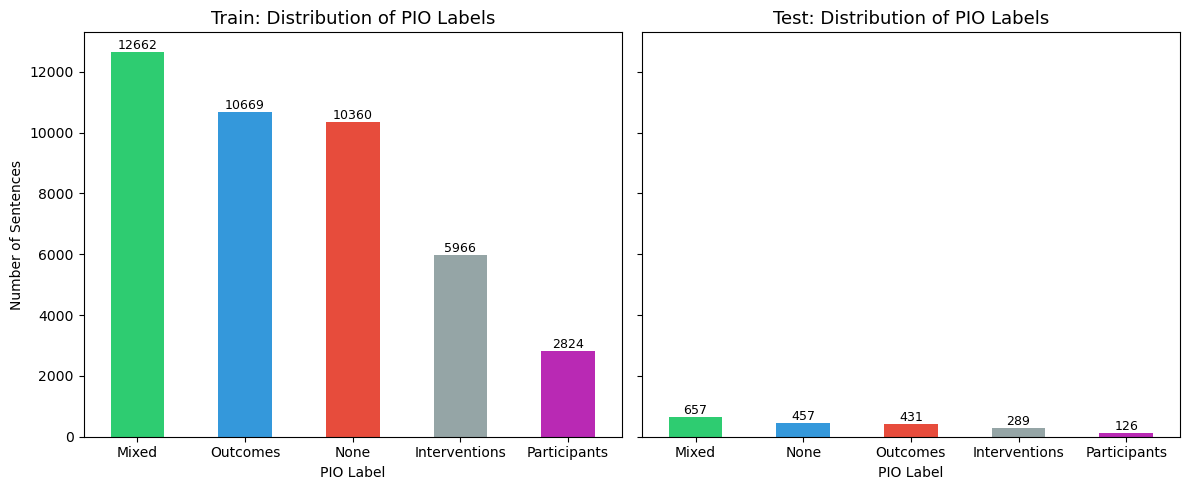

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

label_mapping = {
    "NONE": "None",
    "MIXED": "Mixed",
    "P": "Participants",
    "I": "Interventions",
    "O": "Outcomes"
}

print(f"Train_Sentence_df: {sentence_records_df.shape}")
print(f"Test_Sentence_df: {sentence_test_records_df.shape}\n")
print(f"Train_Label_Count: {sentence_records_df["gold_label"].value_counts().rename(index=label_mapping)}\n")
print(f"Test_Label_Count: {sentence_test_records_df["gold_label"].value_counts().rename(index=label_mapping)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Train plot
sentence_records_df["gold_label"].value_counts().rename(index=label_mapping).plot(kind="bar",ax=axes[0], color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6",  "#b929b4"])
axes[0].set_title("Train: Distribution of PIO Labels", fontsize=13)
axes[0].set_xlabel("PIO Label")
axes[0].set_ylabel("Number of Sentences")
axes[0].tick_params(axis="x", rotation=0)

for i in axes[0].containers:
    axes[0].bar_label(i, fontsize=9)

# Test plot
sentence_test_records_df["gold_label"].value_counts().rename(index=label_mapping).plot(kind="bar",ax=axes[1], color=["#2ecc71", "#3498db", "#e74c3c", "#95a5a6",  "#b929b4"])
axes[1].set_title("Train: Distribution of PIO Labels", fontsize=13)
axes[1].set_title("Test: Distribution of PIO Labels", fontsize=13)
axes[1].set_xlabel("PIO Label")
axes[1].tick_params(axis="x", rotation=0)

for i in axes[1].containers:
    axes[1].bar_label(i, fontsize=9)

plt.tight_layout()
plt.show()

MIXED is the most common label, followed by NONE/O/I, with P being the least frequent.

In [51]:
sentence_records_df.head()

,doc_id,sentence_id,sentence_start,sentence_end,sentence_text,sentence_tokens,p_bio,i_bio,o_bio,p_count,i_count,o_count,gold_label
0,10036953,0,0,15,[Triple therapy regimens involving H2 blockade...,"[[, Triple, therapy, regimens, involving, H2, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]","[O, O, O, O, O, B, I, O, O, O, O, O, O, O, O]","[O, O, O, O, O, O, O, O, O, O, B, I, I, I, O]",0,2,4,MIXED
1,10036953,1,15,30,Comparison of ranitidine and lansoprazole in s...,"[Comparison, of, ranitidine, and, lansoprazole...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O]","[O, O, B, O, B, O, O, O, O, O, O, O, O, O, O]","[B, O, O, O, O, O, O, O, O, O, O, O, O, O, O]",0,2,1,MIXED
2,10036953,2,30,83,To evaluate the efficacy and safety of two 1-w...,"[To, evaluate, the, efficacy, and, safety, of,...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, B, ...","[O, O, O, B, I, I, O, O, O, O, O, O, O, O, O, ...",4,12,3,MIXED
3,10036953,3,83,110,The drug combination and administration period...,"[The, drug, combination, and, administration, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, B, O, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",0,3,0,I
4,10036953,4,110,130,"The ranitidine group received RNT 300 mg, CAM ...","[The, ranitidine, group, received, RNT, 300, m...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...","[O, B, O, O, B, O, O, O, B, O, O, O, B, O, O, ...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ...",0,4,0,I


In [52]:
def load_label_records(doc_ids, label_type = "participants", split = "train"):

    records = []

    for doc_id in doc_ids:
        tokens = load_document(doc_id)
        labels_raw = load_labels_for_doc(doc_id, label_type, split)
        labels_bio = hierarchical_to_bio(labels_raw)
   
        records.append({
            "doc_id": doc_id,
            "label_type": label_type,
            "split": split,
            "tokens": tokens,
            "labels_raw": labels_raw,
            "labels_bio": labels_bio,
        })

In [53]:
from pathlib import Path

output_dir = Path('../outputs')

baseline_dfs = {
    'sentence_records_df': sentence_records_df,
    'sentence_test_records_df': sentence_test_records_df
}

output_dir.mkdir(parents=True, exist_ok=True)

for name, df in baseline_dfs.items():
    filepath = output_dir/f'{name}.csv'
    df.to_csv(filepath, index=False)

### EDA and Preprocessing Summary: 
Constructed a sentence-level dataset by (1) loading tokenized abstracts and hierarchical P/I/O labels, (2) validating token-label alignment, (3) splitting tokens into sentence spans, (4) detokenizing each span into sentence text, and (5) assigning sentence-level gold labels based on the presence of P/I/O tokens.